# Prediccion del Tipo de Cambio USD/GEL con MLP

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('USD_GEL Historical Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

features = ['Price', 'Open', 'High', 'Low']
data_raw = df[features].values.astype(np.float32)

print(f"Registros totales: {len(df)}")
print(f"Features: {features} → {data_raw.shape}")

ModuleNotFoundError: No module named 'matplotlib'

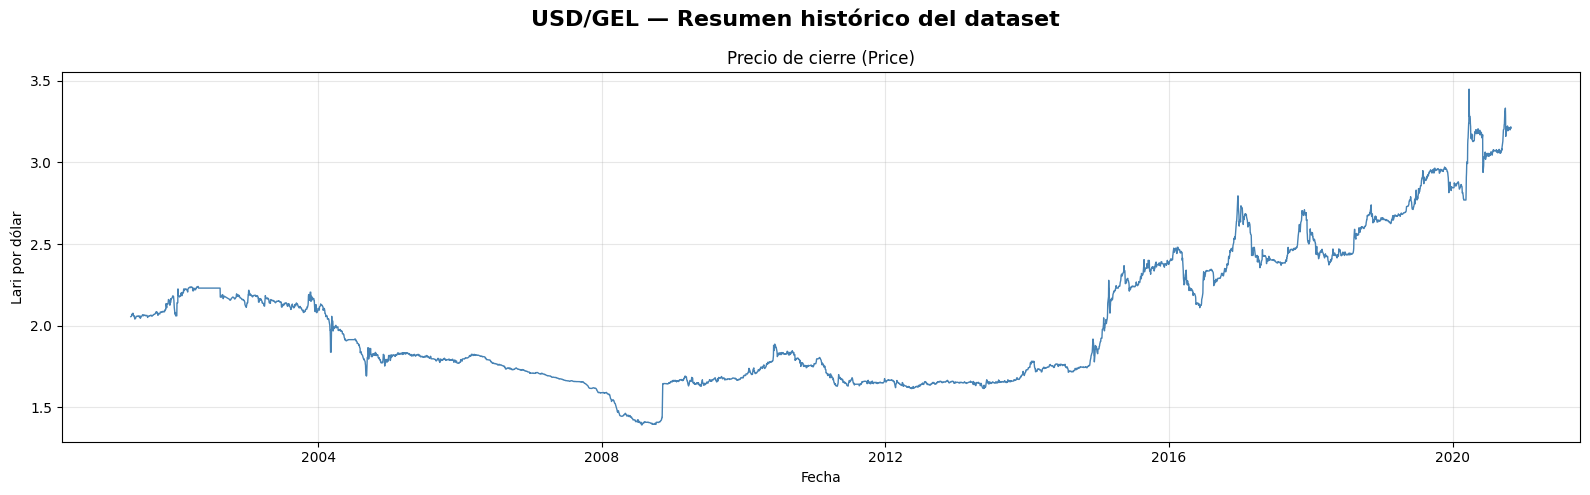

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
fig.suptitle('USD/GEL — Resumen histórico del dataset', fontsize=16, fontweight='bold')

ax.plot(df['Date'], df['Price'], color='steelblue', linewidth=1)
ax.set_title('Precio de cierre (Price)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Lari por dólar')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
n_steps = 14

def create_windows(data, steps):
    X = np.array([data[i:i + steps] for i in range(len(data) - steps)], dtype=np.float32)
    y = np.array([[data[i + steps, 0]] for i in range(len(data) - steps)], dtype=np.float32)  # target_idx=0 (Price)
    return X, y

n = len(data_raw) - n_steps
train_end = int(n * 0.70)
val_end = int(n * 0.85)

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(data_raw[:train_end + n_steps])

data_scaled = scaler.transform(data_raw).astype(np.float32)

X_all, y_all = create_windows(data_scaled, n_steps)
X_train, y_train = X_all[:train_end], y_all[:train_end]
X_valid, y_valid = X_all[train_end:val_end], y_all[train_end:val_end]
X_test, y_test = X_all[val_end:], y_all[val_end:]

y_dates = df['Date'].iloc[n_steps:].reset_index(drop=True)
test_dates = y_dates.iloc[val_end:].reset_index(drop=True)

print(f"\nDatos normalizados")
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Valid: {X_valid.shape}, {y_valid.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")


Datos normalizados
Train: (3489, 14, 4), (3489, 1)
Valid: (748, 14, 4), (748, 1)
Test:  (748, 14, 4), (748, 1)


In [ ]:
print(df.describe())

                             Date        Price         Open         High  \
count                        4999  4999.000000  4999.000000  4999.000000   
mean   2011-03-23 23:40:24.724945     2.023289     2.028757     2.033676   
min           2001-05-11 00:00:00     1.391300     1.391300     1.391300   
25%           2006-06-14 12:00:00     1.672600     1.672500     1.675000   
50%           2011-03-30 00:00:00     1.819300     1.819400     1.820500   
75%           2016-01-12 12:00:00     2.318150     2.336250     2.350350   
max           2020-10-27 00:00:00     3.449600     3.491700     3.540000   
std                           NaN     0.426543     0.432526     0.435905   

               Low  
count  4999.000000  
mean      2.025624  
min       1.391300  
25%       1.673950  
50%       1.820000  
75%       2.322400  
max       3.380600  
std       0.427210  


Nuestro objetivo es **predecir el precio de cierre del día siguiente** a partir de los `n_steps` días anteriores. Si un modelo logra hacer esto con precisión, podría ser útil como señal en estrategias de análisis financiero o para monitorear la volatilidad del tipo de cambio USD/GEL.

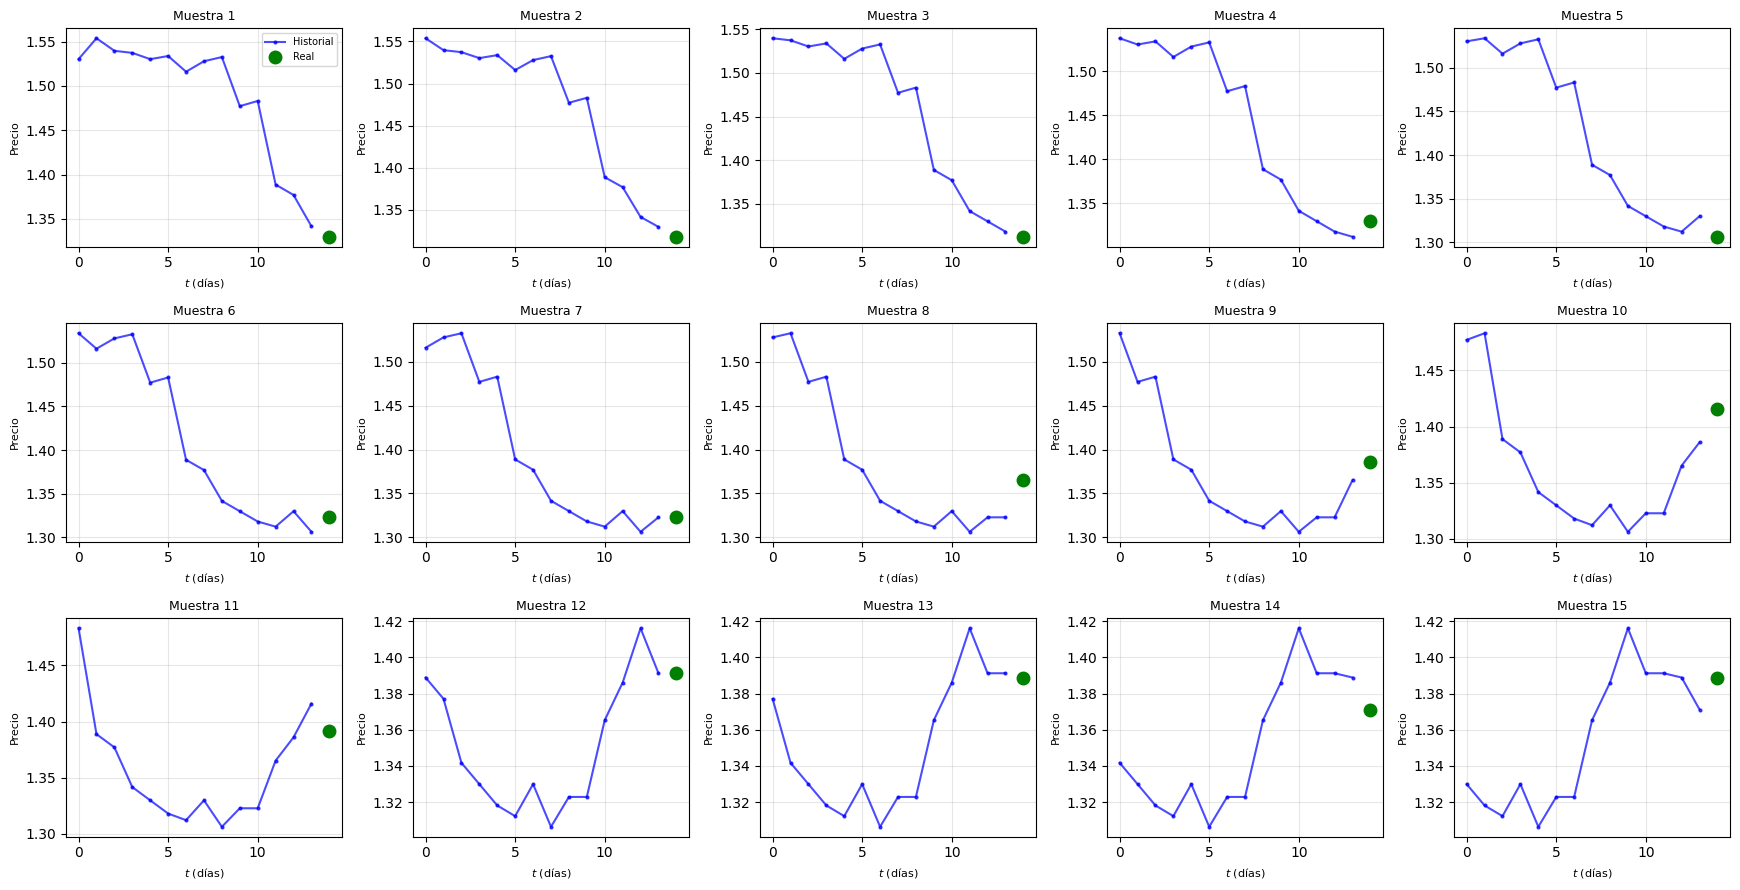

In [ ]:
def plot_series(X, y=None, y_pred=None, x_label='$t$ (días)', y_label='Precio', n_plots=15):
    n = min(n_plots, len(X))
    cols = 5
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3))
    axes = axes.flatten()

    for idx in range(n):
        ax = axes[idx]
        ax.plot(X[idx, :, 0], 'b.-', linewidth=1.5, markersize=4, alpha=0.7, label='Historial')
        t = len(X[idx, :, 0])
        if y is not None:
            ax.plot([t], y[idx], 'go', markersize=9, label='Real', zorder=5)
        if y_pred is not None:
            val = y_pred[idx] if hasattr(y_pred[idx], '__len__') else [y_pred[idx]]
            ax.plot([t], val, 'r^', markersize=9, label='Predicción', zorder=5)
        ax.set_title(f'Muestra {idx + 1}', fontsize=9)
        ax.set_xlabel(x_label, fontsize=8)
        ax.set_ylabel(y_label, fontsize=8)
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=7)

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

# Visualizar 15 ventanas del conjunto de prueba USD/GEL con su valor objetivo
# El eje Y muestra el precio normalizado [0, 1]
plot_series(X_test, y_test, x_label="$t$ (días)", y_label="Precio")

### Predicción *Naive*

Un modelo de referencia muy sencillo consiste en predecir que el precio del día siguiente será igual al precio del último día conocido. A pesar de su simplicidad, este modelo puede ser difícil de superar en series financieras con poca volatilidad a corto plazo.

In [ ]:
from sklearn.metrics import mean_squared_error

# Predicción naive: el precio del día siguiente = último precio conocido de la ventana
y_pred_naive = X_test[:, -1, 0].reshape(-1, 1)
mean_squared_error(y_test, y_pred_naive)

0.0005073933280073106

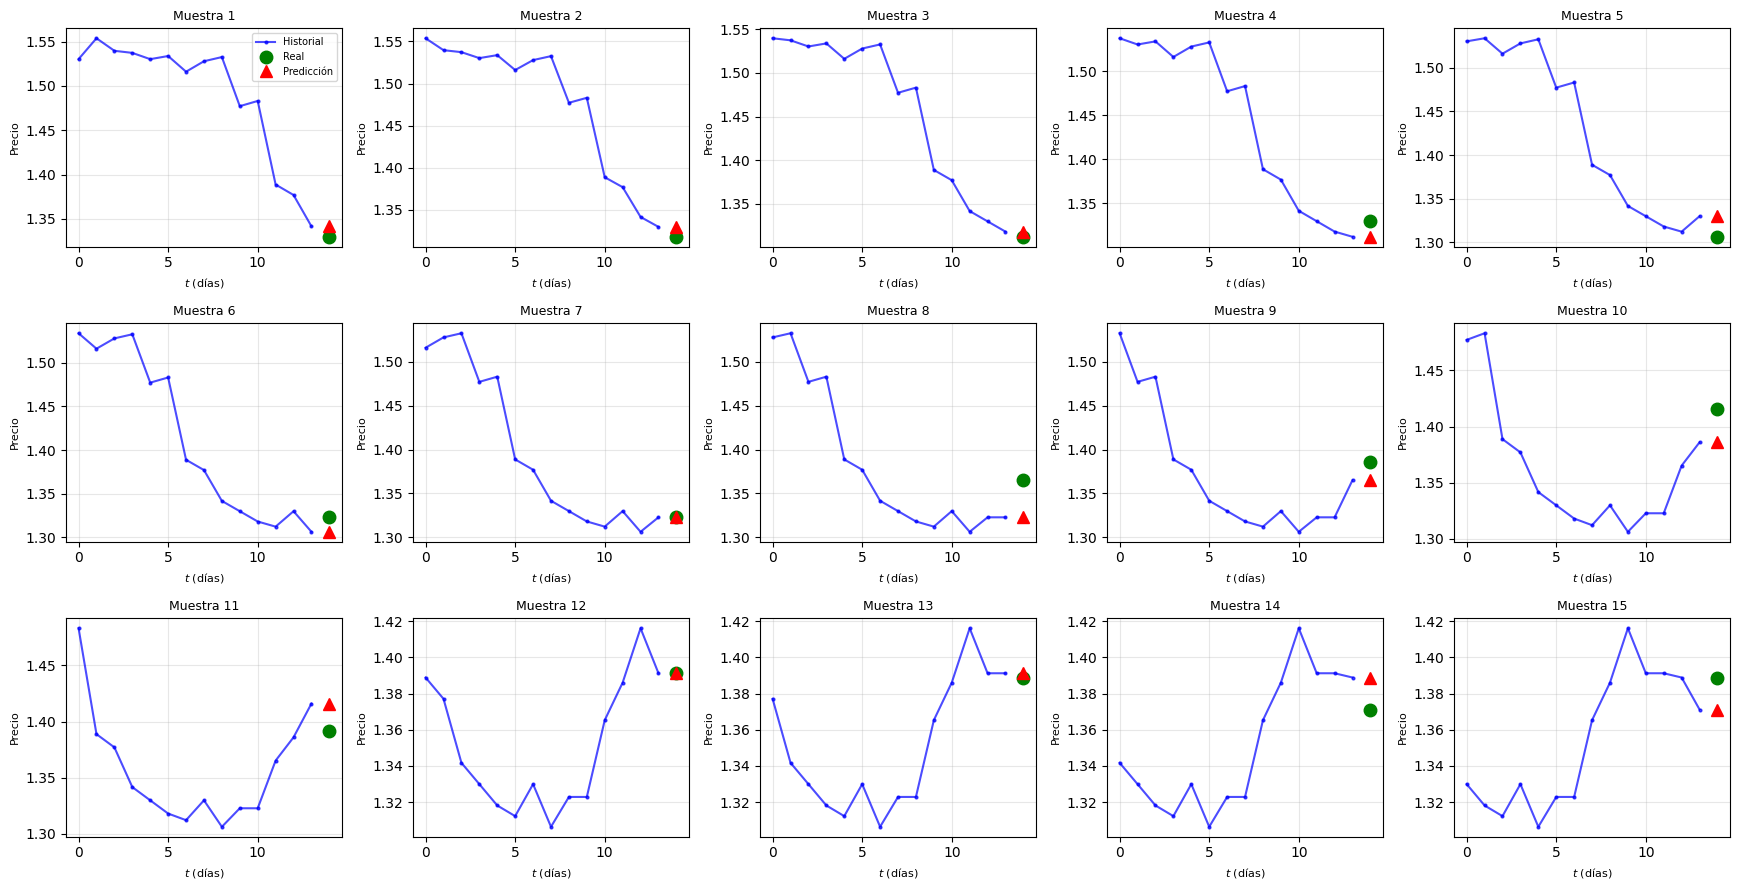

In [ ]:
plot_series(X_test, y_test, y_pred_naive)

Como se puede ver, este modelo tan simple tiene un rendimiento razonable: en series financieras, el precio del día anterior suele ser una buena estimación del precio del día siguiente. Este resultado es el **umbral mínimo** que cualquier modelo más complejo debería superar.

### Perceptrón Multicapa

Dado que todas las ventanas tienen la misma longitud (`n_steps`), podemos intentar resolver el problema con un `MLP` estándar. Aunque no captura dependencias temporales de forma explícita, puede aprender correlaciones lineales útiles si los patrones son suficientemente regulares.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
  def __init__(self, X, y=None, train=True):
    self.X = X
    self.y = y
    self.train = train

  def __len__(self):
    return len(self.X)

  def __getitem__(self, ix):
    if self.train:
      return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
    return torch.from_numpy(self.X[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, y_train),
    'eval': TimeSeriesDataset(X_valid, y_valid),
    'test': TimeSeriesDataset(X_test, y_test, train=False)
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=False, batch_size=16),
    'eval': DataLoader(dataset['eval'], shuffle=False, batch_size=16),
    'test': DataLoader(dataset['test'], shuffle=False, batch_size=16)
}

In [9]:
class MLP(torch.nn.Module):
  def __init__(self, n_steps=14, n_features=4, n_out=1):
    super().__init__()
    
    self.fc = torch.nn.Sequential(
        torch.nn.Linear(n_steps * n_features, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, n_out)
    )

  def forward(self, x):
    x = x.view(x.shape[0], -1)
    x = self.fc(x)
    return x

mlp = MLP(n_steps=n_steps, n_features=X_train.shape[2])
mlp

NameError: name 'torch' is not defined

In [10]:
from tqdm import tqdm
device = "cuda" if torch.cuda.is_available() else "cpu"

def fit(model, dataloader, epochs=250, early_stopping=20, lr=None, batch_size=None):
    model.to(device)
    
    if lr is None:
        has_lstm = any(isinstance(m, torch.nn.LSTM) for m in model.modules())
        lr = 5e-4 if has_lstm else 1e-4
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.6, patience=8)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs+1))
    best_loss, step = float('inf'), 0
    
    for epoch in bar:
        model.train()
        train_loss, train_acc = [], []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss.append(loss.item())
            train_acc.append((torch.abs(y_hat - y) < 0.10).float().mean().item())
        
        model.eval()
        eval_loss, eval_acc = [], []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                eval_loss.append(loss.item())
                eval_acc.append((torch.abs(y_hat - y) < 0.10).float().mean().item())
        
        mean_train_loss = np.mean(train_loss)
        mean_eval_loss = np.mean(eval_loss)
        mean_train_acc = np.mean(train_acc)
        mean_eval_acc = np.mean(eval_acc)
        bar.set_description(f"loss {mean_train_loss:.5f} val_loss {mean_eval_loss:.5f} acc {mean_train_acc:.5f} val_acc {mean_eval_acc:.5f}")
        
        scheduler.step(mean_eval_loss)
        
        if mean_eval_loss < best_loss:
            best_loss = mean_eval_loss
            step = 0
        else:
            step += 1
        
        if early_stopping and step > early_stopping:
            break

def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X = batch
            X = X.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
        return preds

ModuleNotFoundError: No module named 'tqdm'

In [8]:
print("Entrenando MLP...")
fit(mlp, dataloader, epochs=250, early_stopping=10)

Entrenando MLP...


NameError: name 'fit' is not defined

In [3]:
y_pred = predict(mlp, dataloader['test'])
plot_series(X_test, y_test, y_pred.cpu().numpy())
mean_squared_error(y_test, y_pred.cpu().numpy())

NameError: name 'predict' is not defined

El `MLP` logra mejorar (o al menos igualar) la predicción ingenua. Este modelo es más práctico para **pronóstico autoregresivo**, donde cada predicción se usa como entrada para el siguiente día, permitiendo proyectar indefinidamente hacia el futuro.

## Pronóstico Futuro: Predicción Autoregresiva

Implementamos un enfoque **many-to-one autoregresivo**, este diseño es más práctico para **predecir valores futuros** porque permite generar pronósticos a cualquier horizonte mediante iteración: cada predicción se usa como entrada para el siguiente día, sin limitarse a los datos conocidos del dataset.

In [ ]:
horizon = 30

last_window = data_scaled[-n_steps:].astype(np.float32).copy()
future_scaled = []

mlp.eval()
for _ in range(horizon):
    x_in = torch.from_numpy(last_window).unsqueeze(0).to(device=device, dtype=torch.float32)
    
    with torch.no_grad():
        next_scaled = mlp(x_in).item()
    
    next_scaled = float(np.clip(next_scaled, 0.0, 1.0))
    future_scaled.append(next_scaled)
    
    new_row = last_window[-1].copy().reshape(1, -1)
    new_row[0, 0] = next_scaled
    last_window = np.concatenate([last_window[1:], new_row], axis=0).astype(np.float32)

price_min = scaler.data_min_[0]
price_range = scaler.data_range_[0]
future_prices = np.array(future_scaled) * price_range + price_min

today = df['Date'].iloc[-1]
future_dates = pd.date_range(start=today + pd.Timedelta(days=1), periods=horizon, freq='D')

future_df = pd.DataFrame({
    'Date': future_dates,
    'Prediccion_USD_GEL': future_prices,
})

print(f"PRONÓSTICO A {horizon} DÍAS - MODELO MLP")
print(future_df)
print(f"\nÚltimo precio histórico ({today.date()}): {df['Price'].iloc[-1]:.4f} GEL/USD")
print(f"Precio predicho día {horizon}: {future_df['Prediccion_USD_GEL'].iloc[-1]:.4f} GEL/USD")

NameError: name 'data_scaled' is not defined

In [ ]:
# Verificar manualmente el rango
print(f"data_min_[0] = {scaler.data_min_[0]:.4f}")
print(f"data_range_[0] = {scaler.data_range_[0]:.4f}")
print(f"Último precio real = {df['Price'].iloc[-1]:.4f}")
print(f"Último valor escalado = {data_scaled[-1, 0]:.4f}")

# El valor escalado invertido debería coincidir con el precio real:
reconstruido = data_scaled[-1, 0] * scaler.data_range_[0] + scaler.data_min_[0]
print(f"Reconstruido = {reconstruido:.4f}") 


NameError: name 'scaler' is not defined


Últimos 180 registros: desde 2020-02-19 hasta 2020-10-27


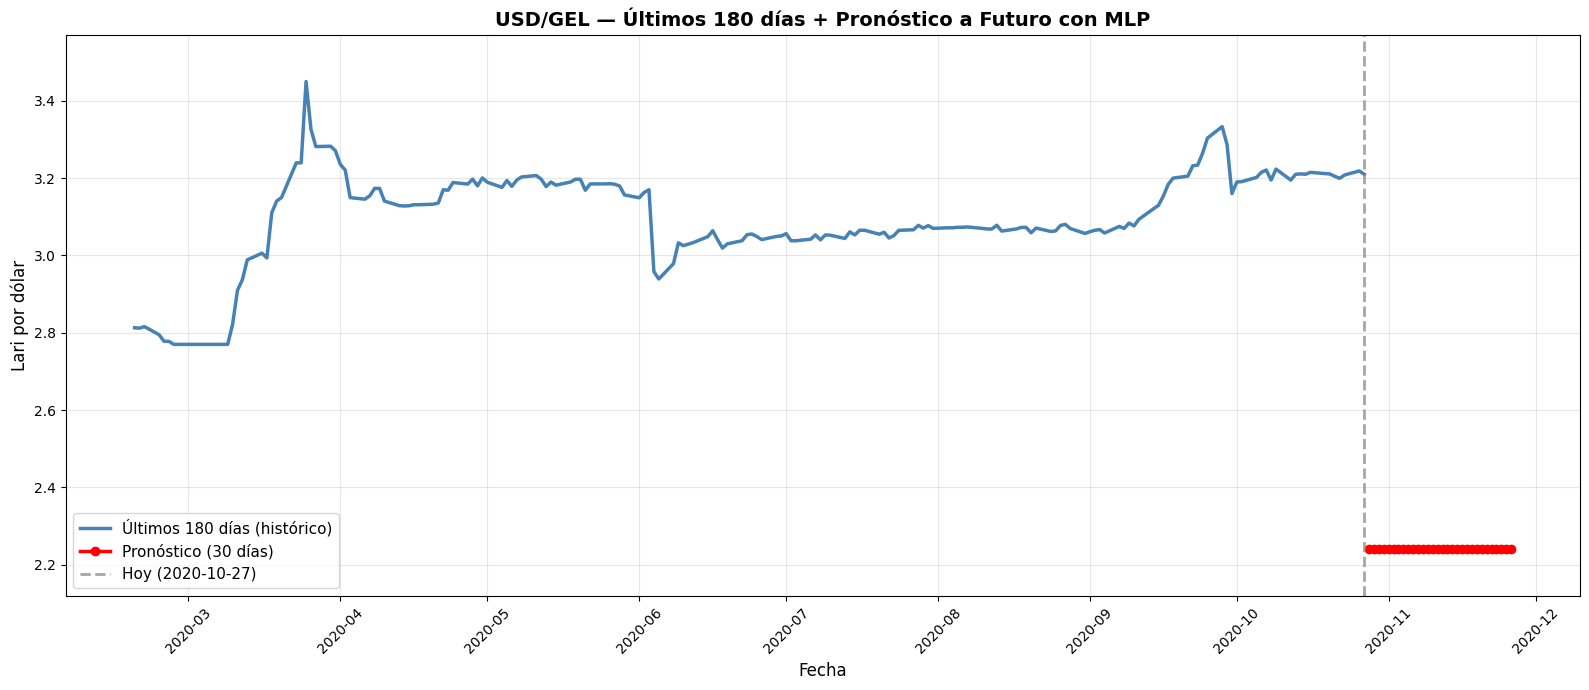

In [ ]:
plt.figure(figsize=(16, 7))

historical_recent = df.tail(180)

print(f"\nÚltimos 180 registros: desde {historical_recent['Date'].iloc[0].date()} hasta {historical_recent['Date'].iloc[-1].date()}")

plt.plot(historical_recent['Date'], historical_recent['Price'], linewidth=2.5, color='steelblue', label='Últimos 180 días (histórico)')

plt.plot(future_df['Date'], future_df['Prediccion_USD_GEL'], 'o-',
         linewidth=2.5, color='red', markersize=6, label='Pronóstico (30 días)')

plt.axvline(today, color='gray', linestyle='--', alpha=0.7, linewidth=2, label=f'Hoy ({today.date()})')

all_prices = np.concatenate([historical_recent['Price'].values, future_df['Prediccion_USD_GEL'].values])
y_min, y_max = all_prices.min(), all_prices.max()
y_margin = (y_max - y_min) * 0.1
plt.ylim(y_min - y_margin, y_max + y_margin)

plt.title('USD/GEL — Últimos 180 días + Pronóstico a Futuro con MLP', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Lari por dólar', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Red Neuronal Recurrente: LSTM (Long Short-Term Memory)

El **LSTM** es una mejora fundamental sobre las RNN tradicionales. Mientras que las RNN simples sufren del problema de gradientes desvanecientes, el LSTM introduce **compuertas** (gates) que controlan el flujo de información:

- **Puerta de olvido (Forget Gate)**: Decide qué información descartar del estado de largo plazo
- **Puerta de entrada (Input Gate)**: Decide qué nueva información añadir al estado de largo plazo
- **Puerta de salida (Output Gate)**: Decide qué información del estado interno pasar al siguiente paso

Esta arquitectura permite mantener dependencias a largo plazo de forma efectiva, lo que resulta en mejor rendimiento en series temporales comparado con el MLP.

In [ ]:
class LSTM(torch.nn.Module):
    def __init__(self, input_size=4, hidden_size=128, num_layers=1, output_size=1, dropout=0.0):
        super().__init__()
        self.lstm = torch.nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                                   num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = torch.nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        lstm_out, (h, c) = self.lstm(x)
        y = self.fc(lstm_out[:, -1])
        return y

lstm_model = LSTM(input_size=X_train.shape[2], hidden_size=128, num_layers=1, output_size=1, dropout=0.0)
print("Modelo LSTM:")
print(lstm_model)

Modelo LSTM:
LSTM(
  (lstm): LSTM(4, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
print("Entrenando modelo LSTM")
fit(lstm_model, dataloader, epochs=500, early_stopping=60)

Entrenando modelo LSTM


loss 0.00010 val_loss 0.00111 acc 0.99886 val_acc 0.99202: 100%|██████████| 500/500 [16:43<00:00,  2.01s/it]   


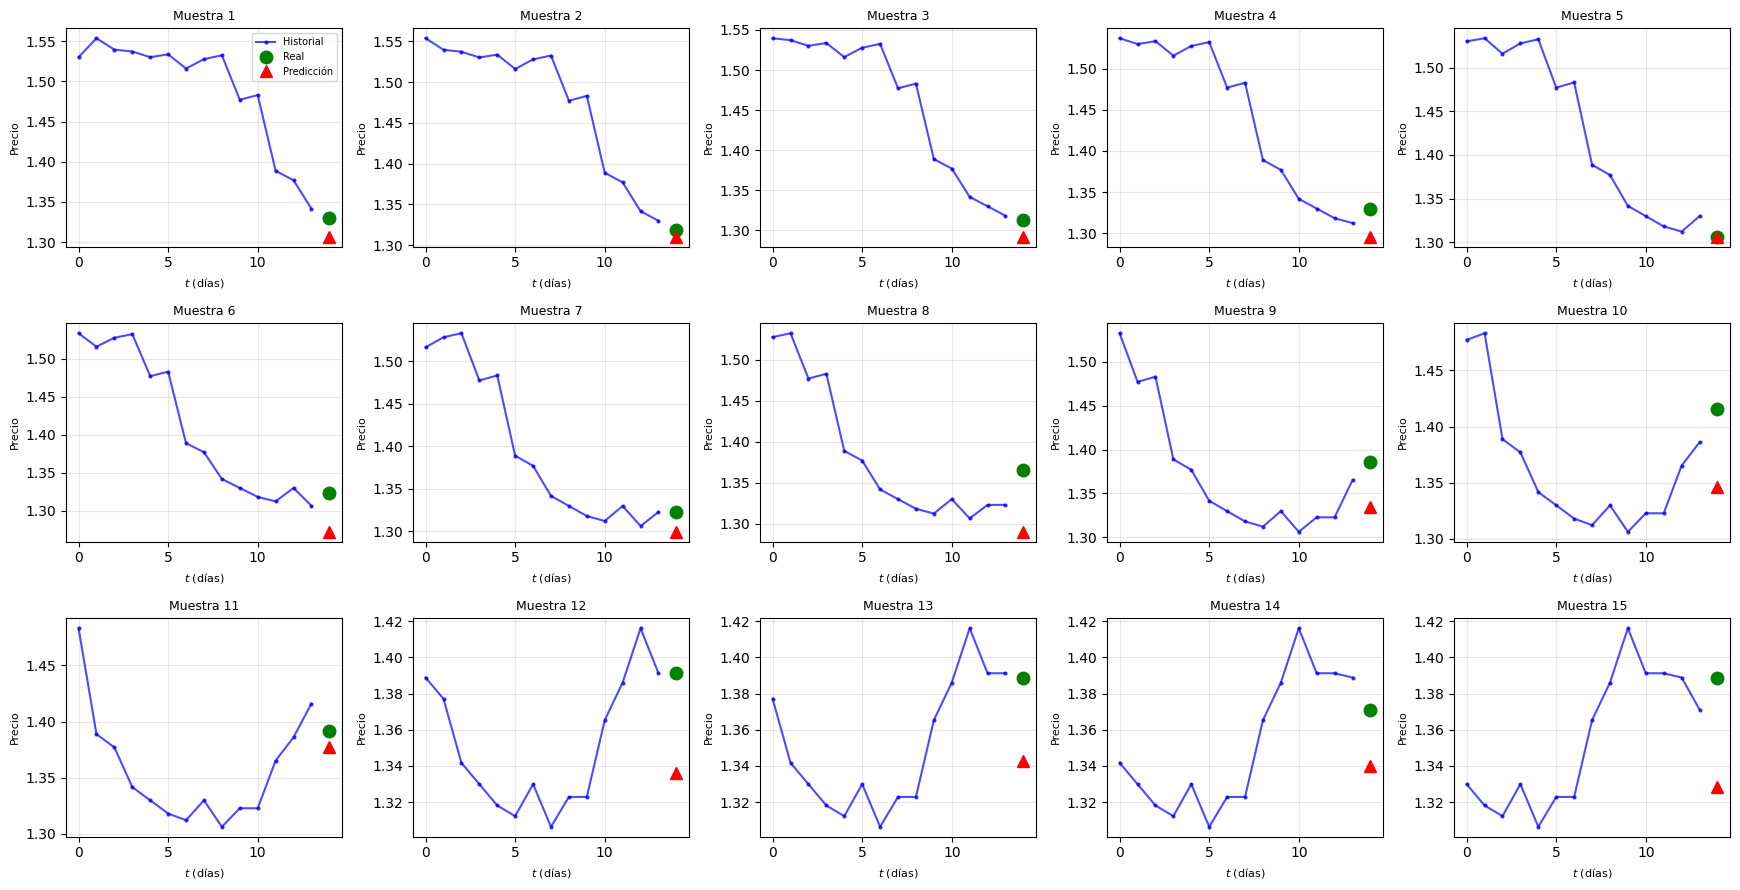


MSE LSTM: 0.01278533
RMSE LSTM: 0.11307222


In [ ]:
y_pred_lstm = predict(lstm_model, dataloader['test']).cpu().numpy()
plot_series(X_test, y_test, y_pred_lstm)
mse_lstm = mean_squared_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
print(f"\nMSE LSTM: {mse_lstm:.8f}")
print(f"RMSE LSTM: {rmse_lstm:.8f}")

## Comparativa: MLP vs LSTM

En esta sección comparamos el desempeño de los dos modelos principales: el **Perceptrón Multicapa (MLP)** y el **LSTM**. Ambos fueron entrenados con datos normalizados para predecir el precio del día siguiente del USD/GEL.

In [ ]:
y_pred_mlp = predict(mlp, dataloader['test']).cpu().numpy()
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
mae_mlp = np.mean(np.abs(y_test - y_pred_mlp))

mae_lstm = np.mean(np.abs(y_test - y_pred_lstm))

comparison_table = pd.DataFrame({
    'Modelo': ['MLP', 'LSTM'],
    'MSE': [mse_mlp, mse_lstm],
    'RMSE': [rmse_mlp, rmse_lstm],
    'MAE': [mae_mlp, mae_lstm],
    'Parámetros': ['MLP (feed-forward)', 'LSTM con compuertas'],
    'Capas': ['1 oculta', '2 LSTM + 1 FC']
})

print("COMPARATIVA DE MODELOS: MLP vs LSTM")
print(comparison_table.to_string(index=False))

mejora_mse = ((mse_mlp - mse_lstm) / mse_mlp) * 100
mejora_rmse = ((rmse_mlp - rmse_lstm) / rmse_mlp) * 100
mejora_mae = ((mae_mlp - mae_lstm) / mae_mlp) * 100

print(f"\nMEJORA DEL LSTM SOBRE MLP:")
print(f"   • MSE:  {mejora_mse:+.2f}% {'✓ mejor' if mejora_mse > 0 else '✗ peor'}")
print(f"   • RMSE: {mejora_rmse:+.2f}% {'✓ mejor' if mejora_rmse > 0 else '✗ peor'}")
print(f"   • MAE:  {mejora_mae:+.2f}% {'✓ mejor' if mejora_mae > 0 else '✗ peor'}")

COMPARATIVA DE MODELOS: MLP vs LSTM
Modelo      MSE     RMSE      MAE          Parámetros         Capas
   MLP 0.013481 0.116108 0.107067  MLP (feed-forward)      1 oculta
  LSTM 0.012785 0.113072 0.094905 LSTM con compuertas 2 LSTM + 1 FC

MEJORA DEL LSTM SOBRE MLP:
   • MSE:  +5.16% ✓ mejor
   • RMSE: +2.61% ✓ mejor
   • MAE:  +11.36% ✓ mejor


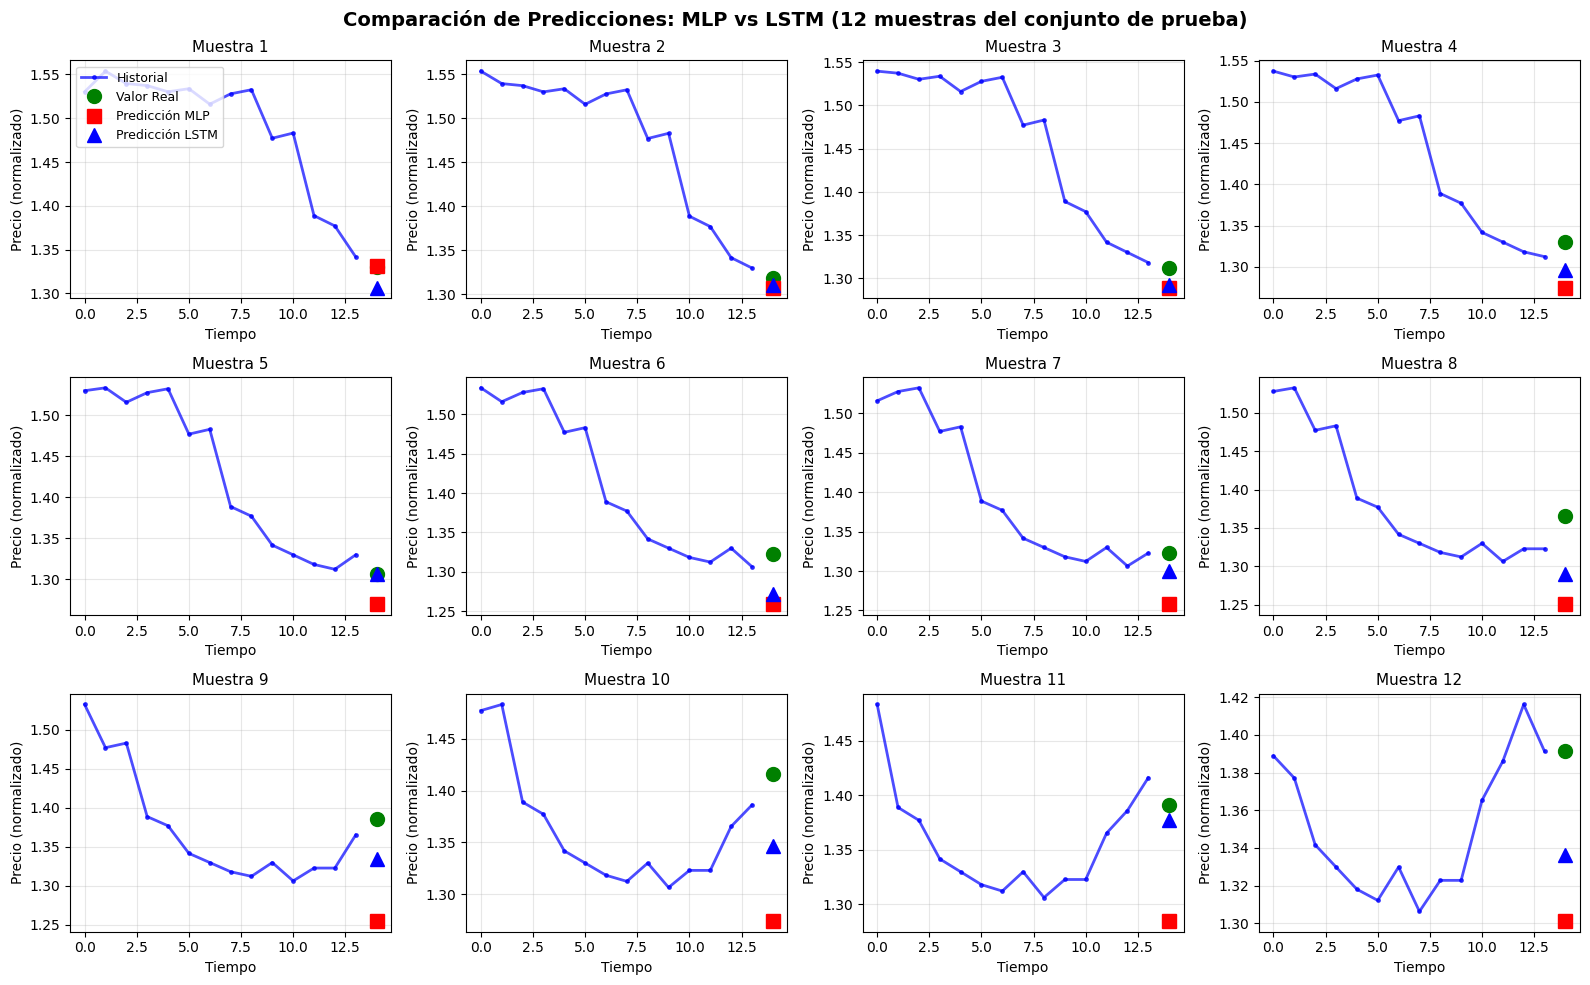

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for idx in range(12):
    ax = axes[idx]
    
    x_seq = X_test[idx, :, 0]
    ax.plot(x_seq, 'b.-', label='Historial', linewidth=2, markersize=5, alpha=0.7)
    
    ax.plot([len(x_seq)], y_test[idx], 'go', markersize=10, label='Valor Real', zorder=5)
    ax.plot([len(x_seq)], y_pred_mlp[idx], 'rs', markersize=10, label='Predicción MLP', zorder=5)
    ax.plot([len(x_seq)], y_pred_lstm[idx], 'b^', markersize=10, label='Predicción LSTM', zorder=5)
    
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Muestra {idx+1}', fontsize=11)
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Precio (normalizado)')
    if idx == 0:
        ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Comparación de Predicciones: MLP vs LSTM (12 muestras del conjunto de prueba)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

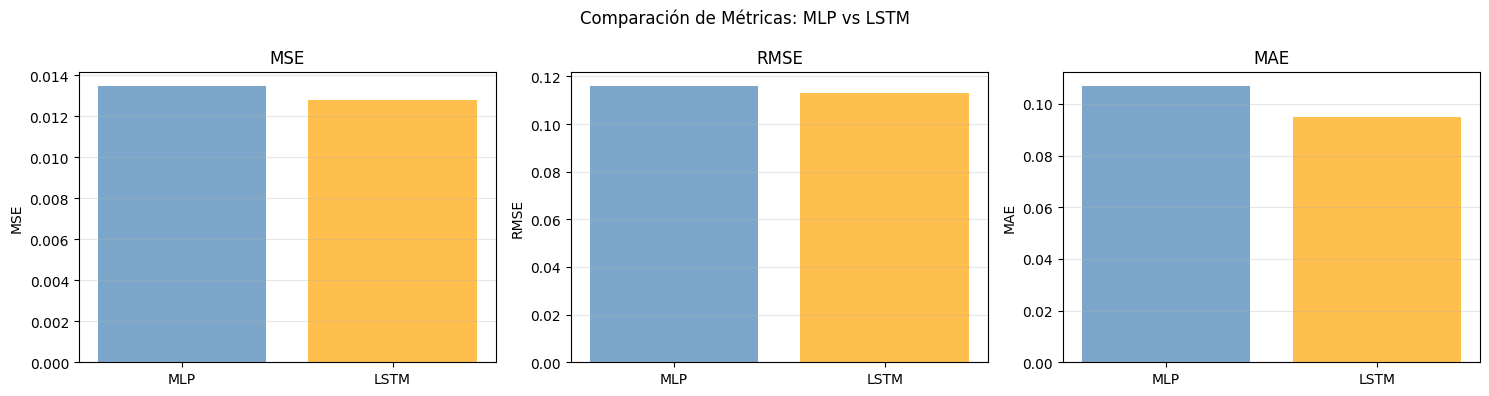

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.bar(['MLP', 'LSTM'], [mse_mlp, mse_lstm], color=['steelblue', 'orange'], alpha=0.7)
ax.set_ylabel('MSE')
ax.set_title('MSE')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(['MLP', 'LSTM'], [rmse_mlp, rmse_lstm], color=['steelblue', 'orange'], alpha=0.7)
ax.set_ylabel('RMSE')
ax.set_title('RMSE')
ax.grid(axis='y', alpha=0.3)

ax = axes[2]
ax.bar(['MLP', 'LSTM'], [mae_mlp, mae_lstm], color=['steelblue', 'orange'], alpha=0.7)
ax.set_ylabel('MAE')
ax.set_title('MAE')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparación de Métricas: MLP vs LSTM')
plt.tight_layout()
plt.show()

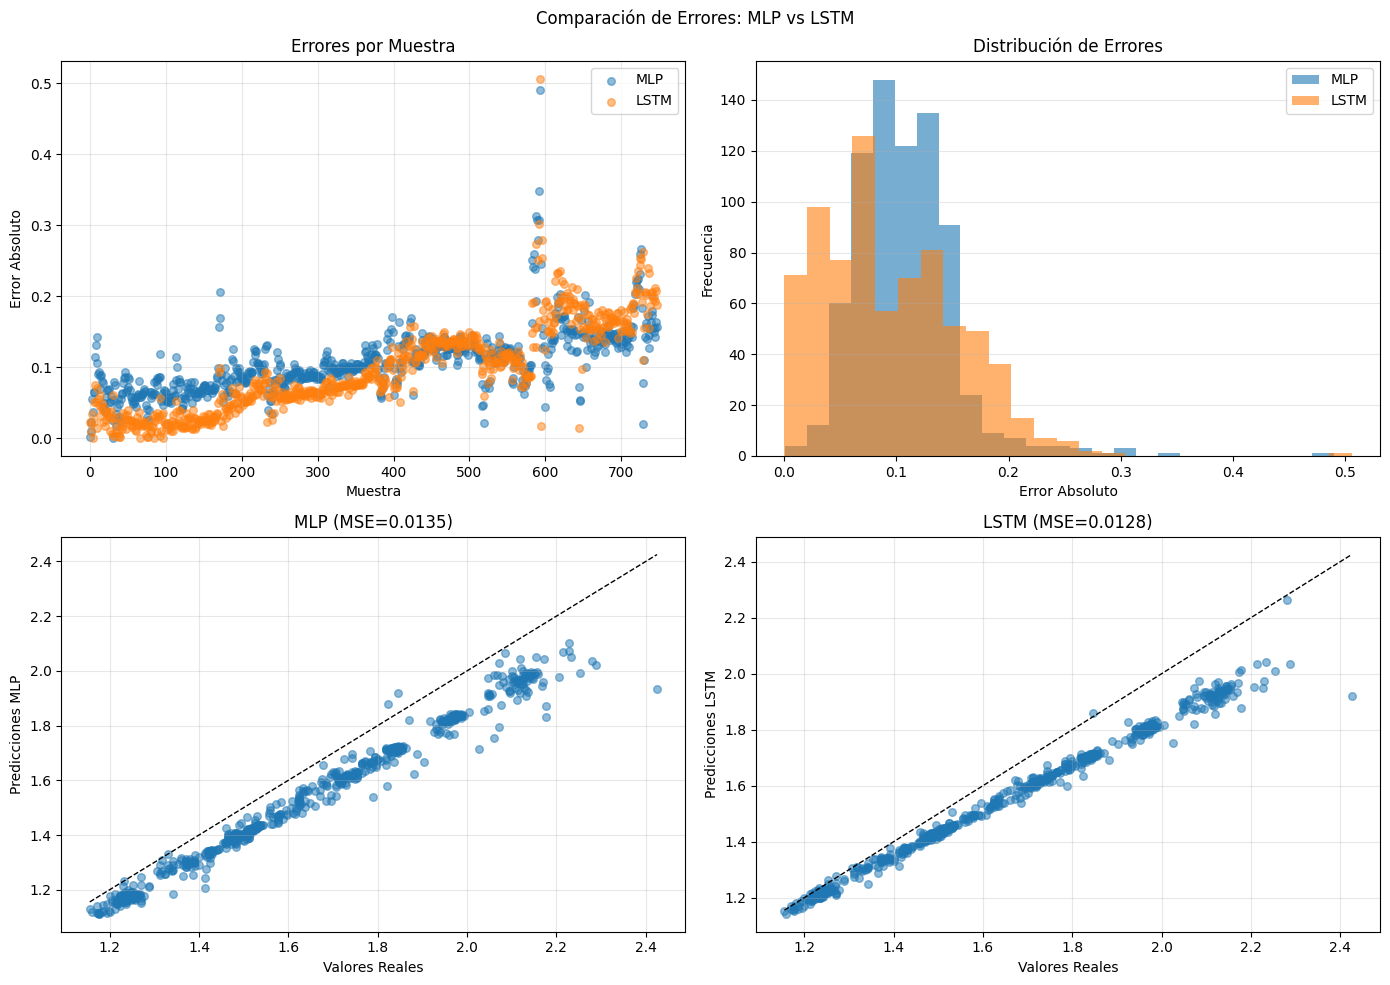

In [ ]:
errores_mlp = np.abs(y_test.flatten() - y_pred_mlp.flatten())
errores_lstm = np.abs(y_test.flatten() - y_pred_lstm.flatten())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.scatter(range(len(errores_mlp)), errores_mlp, alpha=0.5, s=30, label='MLP')
ax.scatter(range(len(errores_lstm)), errores_lstm, alpha=0.5, s=30, label='LSTM')
ax.set_xlabel('Muestra')
ax.set_ylabel('Error Absoluto')
ax.set_title('Errores por Muestra')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.hist(errores_mlp, bins=25, alpha=0.6, label='MLP')
ax.hist(errores_lstm, bins=25, alpha=0.6, label='LSTM')
ax.set_xlabel('Error Absoluto')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Errores')
ax.legend()
ax.grid(axis='y', alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_test, y_pred_mlp, alpha=0.5, s=30)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
ax.set_xlabel('Valores Reales')
ax.set_ylabel('Predicciones MLP')
ax.set_title(f'MLP (MSE={mse_mlp:.4f})')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.scatter(y_test, y_pred_lstm, alpha=0.5, s=30)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
ax.set_xlabel('Valores Reales')
ax.set_ylabel('Predicciones LSTM')
ax.set_title(f'LSTM (MSE={mse_lstm:.4f})')
ax.grid(True, alpha=0.3)

plt.suptitle('Comparación de Errores: MLP vs LSTM')
plt.tight_layout()
plt.show()

## Pronóstico Futuro LSTM: Predicción Autoregresiva a 30 Días

In [ ]:
horizon = 30

last_window = data_scaled[-n_steps:].astype(np.float32).copy()
future_scaled_lstm = []

lstm_model.eval()
for _ in range(horizon):
    x_in = torch.from_numpy(last_window).unsqueeze(0).to(device=device, dtype=torch.float32)
    
    with torch.no_grad():
        next_scaled = lstm_model(x_in).item()
    
    next_scaled = float(np.clip(next_scaled, 0.0, 1.0))
    future_scaled_lstm.append(next_scaled)
    
    new_row = last_window[-1].copy().reshape(1, -1)
    new_row[0, 0] = next_scaled
    last_window = np.concatenate([last_window[1:], new_row], axis=0).astype(np.float32)

future_prices_lstm = np.array(future_scaled_lstm) * price_range + price_min

future_df_lstm = pd.DataFrame({
    'Date': future_dates,
    'Prediccion_USD_GEL_LSTM': future_prices_lstm,
})

print(f"PRONÓSTICO A {horizon} DÍAS - MODELO LSTM")
print(future_df_lstm)
print(f"\nÚltimo precio histórico ({today.date()}): {df['Price'].iloc[-1]:.4f} GEL/USD")
print(f"Precio predicho día {horizon}: {future_df_lstm['Prediccion_USD_GEL_LSTM'].iloc[-1]:.4f} GEL/USD")

PRONÓSTICO A 30 DÍAS - MODELO LSTM
         Date  Prediccion_USD_GEL_LSTM
0  2020-10-28                 2.240000
1  2020-10-29                 2.189264
2  2020-10-30                 2.240000
3  2020-10-31                 2.240000
4  2020-11-01                 2.240000
5  2020-11-02                 2.240000
6  2020-11-03                 2.240000
7  2020-11-04                 2.240000
8  2020-11-05                 2.240000
9  2020-11-06                 2.240000
10 2020-11-07                 2.240000
11 2020-11-08                 2.240000
12 2020-11-09                 2.240000
13 2020-11-10                 2.240000
14 2020-11-11                 2.240000
15 2020-11-12                 2.240000
16 2020-11-13                 2.240000
17 2020-11-14                 2.240000
18 2020-11-15                 2.240000
19 2020-11-16                 2.240000
20 2020-11-17                 2.240000
21 2020-11-18                 2.240000
22 2020-11-19                 2.240000
23 2020-11-20                


Últimos 180 registros: desde 2020-02-19 hasta 2020-10-27


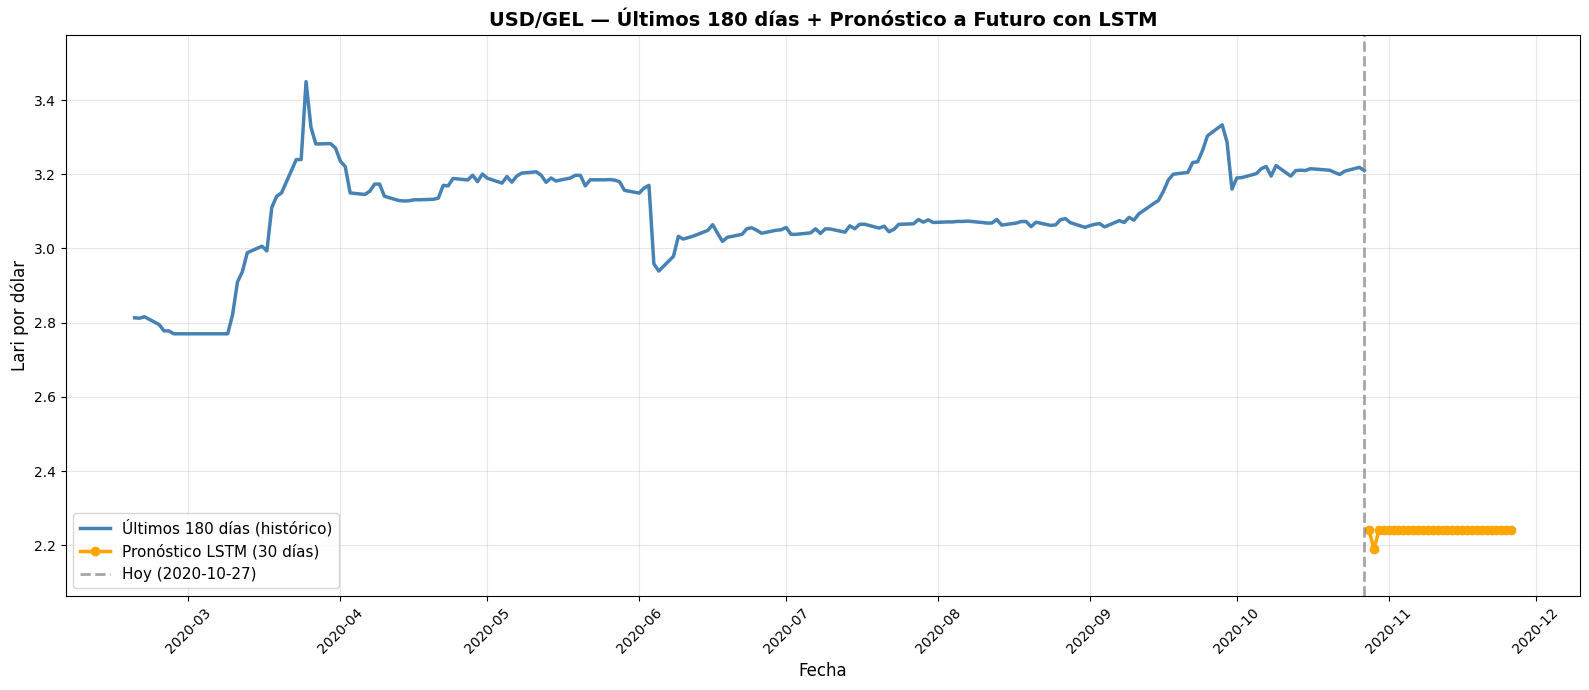

In [ ]:
plt.figure(figsize=(16, 7))

historical_recent = df.tail(180)

print(f"\nÚltimos 180 registros: desde {historical_recent['Date'].iloc[0].date()} hasta {historical_recent['Date'].iloc[-1].date()}")

plt.plot(historical_recent['Date'], historical_recent['Price'], linewidth=2.5, color='steelblue', label='Últimos 180 días (histórico)')

plt.plot(future_df_lstm['Date'], future_df_lstm['Prediccion_USD_GEL_LSTM'], 'o-',
         linewidth=2.5, color='orange', markersize=6, label='Pronóstico LSTM (30 días)')

plt.axvline(today, color='gray', linestyle='--', alpha=0.7, linewidth=2, label=f'Hoy ({today.date()})')

all_prices = np.concatenate([historical_recent['Price'].values, future_df_lstm['Prediccion_USD_GEL_LSTM'].values])
y_min, y_max = all_prices.min(), all_prices.max()
y_margin = (y_max - y_min) * 0.1
plt.ylim(y_min - y_margin, y_max + y_margin)

plt.title('USD/GEL — Últimos 180 días + Pronóstico a Futuro con LSTM', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Lari por dólar', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()